# Posterior Error vs Signed Log Marginal Likelihood Error

This notebook compares posterior approximation error with signed NPE log marginal likelihood error for all generative/source models.

Main diagnostic:

- x-axis: signed log marginal likelihood error,
  \(\widehat{\log p(y\mid M_j)}-\log p(y\mid M_j)\)
- y-axis: posterior error, either MMD or posterior mean RMSE
- each panel: one assumed model \(M_j\)
- color: generative/source model \(M_1,\ldots,M_{12}\)
- marker: whether the dataset is extrapolative for that assumed model

Large logml error is defined as
\[
|\widehat{\log p(y\mid M_j)}-\log p(y\mid M_j)| > 10.
\]

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import benchmark.examples.gaussian.analysis.summry_diagnostic as sd

base_dir = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian")
figure_dir = base_dir / "figures" / "ood_20d_10n_posterior_logml"
figure_dir.mkdir(parents=True, exist_ok=True)

SUMMARY_CONFIGS = {
    "S=D": {
        "result_dir": base_dir / "results" / "ood_20d_10n",
        "posterior_file": "posterior_distance_frame_20d_10n.csv",
        "logml_file": "logml_distance_frame_20d_10n.csv",
    },
    "S=2D": {
        "result_dir": base_dir / "results" / "ood_40d_10n",
        "posterior_file": "posterior_distance_frame_40d_10n.csv",
        "logml_file": "logml_distance_frame_40d_10n.csv",
    },
    "S=4D": {
        "result_dir": base_dir / "results" / "ood_80d_10n",
        "posterior_file": "posterior_distance_frame_80d_10n.csv",
        "logml_file": "logml_distance_frame_80d_10n.csv",
    },
}

SOURCE_COLORS_CB = (
    "#F0E442", "#E69F00", "#009E73", "#CC79A7",
    "#56B4E9", "#D55E00", "#0072B2", "#E011CF",
    "#999999", "#1F03EE", "#882255", "#44AA99",
)
SOURCE_COLOR_MAP = dict(zip(sd.SOURCE_MODELS, SOURCE_COLORS_CB, strict=False))
CLASS_STYLES = {
    False: {"marker": "o", "size": 32, "label": "all high surprise"},
    True: {"marker": "D", "size": 48, "label": "at least one not high surprise"},
}


def load_posterior_logml_frames(config):
    posterior = pd.read_csv(config["result_dir"] / config["posterior_file"])
    logml = pd.read_csv(config["result_dir"] / config["logml_file"])
    merged = posterior.merge(
        logml[["source_model", "id", "assumed_model", "gold_logml", "npe_logml", "signed_logml_error"]],
        on=["source_model", "id", "assumed_model"],
        how="inner",
        validate="one_to_one",
    )
    merged["rho"] = merged["d_M"] / merged["dm_high"]
    merged["large_signed_logml_error"] = merged["signed_logml_error"].abs() > 10.0
    global_flags = (
        merged
        .pivot_table(
            index=["source_model", "id"],
            columns="assumed_model",
            values="distance_regime",
            aggfunc="first",
        )
        .ne("extrapolation")
        .any(axis=1)
        .rename("at_least_one_not_high_surprise")
        .reset_index()
    )
    return merged.merge(global_flags, on=["source_model", "id"], how="left", validate="many_to_one"), posterior, logml


loaded = {label: load_posterior_logml_frames(config) for label, config in SUMMARY_CONFIGS.items()}
merged_by_summary = {label: frames[0] for label, frames in loaded.items()}
posterior_by_summary = {label: frames[1] for label, frames in loaded.items()}
logml_by_summary = {label: frames[2] for label, frames in loaded.items()}

# Keep the original 20d names for the later single-dataset diagnostics.
merged = merged_by_summary["S=D"]
posterior_df = posterior_by_summary["S=D"]
logml_df = logml_by_summary["S=D"]
result_dir = SUMMARY_CONFIGS["S=D"]["result_dir"]

print({label: df.shape for label, df in merged_by_summary.items()})
merged.head()

{'S=D': (2400, 16), 'S=2D': (2400, 16), 'S=4D': (2400, 16)}


,source_model,id,assumed_model,d_M,dm_low,dm_high,distance_regime,posterior_mmd,posterior_mean_rmse,n_posterior_samples,gold_logml,npe_logml,signed_logml_error,rho,large_signed_logml_error,at_least_one_not_high_surprise
0,m1,0,m1,1.106424,0.688625,1.324814,in_distribution,0.013177,0.031069,1000,-329.171074,-329.183557,-0.012483,0.835154,False,True
1,m1,0,m2,2.084169,0.671891,1.335199,extrapolation,1.010025,1.453868,1000,-420.543267,-587.632600,-167.089332,1.560943,True,True
2,m1,0,m3,1.449616,0.736897,1.185308,extrapolation,0.079094,0.440340,1000,-430.114321,-430.297175,-0.182854,1.222986,False,True
3,m1,0,m4,0.922187,0.675210,1.338090,in_distribution,0.012770,0.027867,1000,-329.580450,-329.563801,0.016649,0.689182,False,True
4,m1,1,m1,1.103923,0.688625,1.324814,in_distribution,0.012500,0.025944,1000,-300.431259,-300.407927,0.023333,0.833266,False,True


## Thresholds and Mismatch Labels

The plot uses signed logml error on the x-axis, but the category "large logml error" uses the absolute signed value:

\[
|\mathrm{signed\ logml\ error}| > 10.
\]

For posterior error, the default threshold is the 90% quantile over all source models and assumed models.

In [12]:
posterior_metric = "posterior_mmd"  # or "posterior_mean_rmse"
logml_error_threshold = 10.0
all_merged = pd.concat(merged_by_summary.values(), ignore_index=True)
posterior_error_threshold = float(all_merged[posterior_metric].quantile(0.90))

print("posterior_metric:", posterior_metric)
print("logml_error_threshold:", logml_error_threshold)
print("posterior_error_threshold:", posterior_error_threshold)

posterior_metric: posterior_mmd
logml_error_threshold: 10.0
posterior_error_threshold: 1.0514060974121096


In [13]:
def add_error_categories(df, posterior_metric, logml_threshold, posterior_threshold):
    out = df.copy()
    out["large_logml_error"] = out["signed_logml_error"].abs() > logml_threshold
    out["large_posterior_error"] = out[posterior_metric] > posterior_threshold
    out["logml_error_direction"] = np.select(
        [out["signed_logml_error"] > logml_threshold, out["signed_logml_error"] < -logml_threshold],
        ["positive", "negative"],
        default="small",
    )
    out["error_case"] = np.select(
        [
            out["large_logml_error"] & out["large_posterior_error"],
            out["large_logml_error"] & ~out["large_posterior_error"],
            ~out["large_logml_error"] & out["large_posterior_error"],
        ],
        [
            "high_logml_high_posterior",
            "high_logml_low_posterior",
            "low_logml_high_posterior",
        ],
        default="low_logml_low_posterior",
    )
    return out


categorized = add_error_categories(
    merged,
    posterior_metric=posterior_metric,
    logml_threshold=logml_error_threshold,
    posterior_threshold=posterior_error_threshold,
)

summary = (
    categorized
    .groupby(["source_model", "assumed_model", "error_case", "logml_error_direction"], observed=True)
    .agg(
        n=("id", "size"),
        min_signed_logml_error=("signed_logml_error", "min"),
        max_signed_logml_error=("signed_logml_error", "max"),
        max_posterior_error=(posterior_metric, "max"),
        median_rho=("rho", "median"),
    )
    .reset_index()
    .sort_values(["source_model", "assumed_model", "error_case", "logml_error_direction"])
)

summary

,source_model,assumed_model,error_case,logml_error_direction,n,min_signed_logml_error,max_signed_logml_error,max_posterior_error,median_rho
0,m1,m1,low_logml_low_posterior,small,50,-0.032538,0.031748,0.020035,0.722052
1,m1,m2,high_logml_high_posterior,negative,3,-219.661611,-204.538242,1.085252,1.640030
2,m1,m2,high_logml_low_posterior,negative,47,-184.201298,-16.277608,1.039643,1.693938
3,m1,m3,low_logml_low_posterior,small,50,-1.004931,1.410145,0.117313,1.163637
4,m1,m4,low_logml_low_posterior,small,50,-0.019277,0.022898,0.016787,0.724052
...,...,...,...,...,...,...,...,...,...
62,m9,m2,high_logml_high_posterior,negative,2,-260.405505,-204.102095,1.115582,1.614705
63,m9,m2,high_logml_low_posterior,negative,47,-173.200625,-12.203314,1.024703,1.787611
64,m9,m2,low_logml_low_posterior,small,1,-6.055475,-6.055475,0.279249,1.807070
65,m9,m3,low_logml_low_posterior,small,50,-6.696465,4.521570,0.258662,1.475343


## Representative Mismatch Examples

These are the clearest cases where posterior error and logml error disagree.

In [14]:
cols = [
    "source_model",
    "id",
    "assumed_model",
    "distance_regime",
    "rho",
    "signed_logml_error",
    posterior_metric,
    "error_case",
    "logml_error_direction",
]

high_logml_low_posterior = (
    categorized[categorized["error_case"].eq("high_logml_low_posterior")]
    .assign(_rank=lambda x: x["signed_logml_error"].abs())
    .sort_values("_rank", ascending=False)
    .head(20)
)

low_logml_high_posterior = (
    categorized[categorized["error_case"].eq("low_logml_high_posterior")]
    .sort_values(posterior_metric, ascending=False)
    .head(20)
)

pd.concat([high_logml_low_posterior[cols], low_logml_high_posterior[cols]], ignore_index=True)

,source_model,id,assumed_model,distance_regime,rho,signed_logml_error,posterior_mmd,error_case,logml_error_direction
0,m4,42,m2,extrapolation,1.648876,-192.582630,1.039730,high_logml_low_posterior,negative
1,m7,20,m1,interpolation,0.508727,-191.360769,1.036340,high_logml_low_posterior,negative
2,m8,17,m2,extrapolation,1.571139,-190.930068,1.048485,high_logml_low_posterior,negative
3,m3,18,m2,extrapolation,1.162331,-187.978986,1.051376,high_logml_low_posterior,negative
4,m1,4,m2,extrapolation,1.736837,-184.201298,1.039643,high_logml_low_posterior,negative
5,m10,46,m2,extrapolation,1.772319,-182.092606,1.025815,high_logml_low_posterior,negative
6,m1,18,m2,extrapolation,1.647736,-180.012639,1.038833,high_logml_low_posterior,negative
7,m7,39,m1,in_distribution,0.597146,-179.415769,1.031678,high_logml_low_posterior,negative
8,m4,23,m2,extrapolation,1.591661,-178.735192,1.019448,high_logml_low_posterior,negative
9,m3,7,m2,extrapolation,1.128361,-177.901607,1.038962,high_logml_low_posterior,negative


## Main Diagnostic: Posterior Error vs Signed Logml Error

This figure compares posterior approximation error against signed log marginal likelihood error.

- x-axis: \(\widehat{\log p}(y\mid M_j)-\log p(y\mid M_j)\)
- y-axis: posterior error
- columns: assumed models
- rows: summary dimension \(S=D,2D,4D\) when a dictionary of frames is supplied
- color: source/generative model
- marker: global high-surprise classification

The panel title says `Assumed M_j` because this is not a PMP plot. It uses the same assumed-model columns as the PMP diagnostics, but the y-axis is posterior error.

In [ ]:
def robust_signed_xlim(values, threshold, quantile=1.0):
    finite = np.asarray(values[np.isfinite(values)], dtype=float)
    if finite.size == 0:
        return -1.5 * threshold, 1.5 * threshold
    if quantile >= 1.0:
        low, high = float(np.min(finite)), float(np.max(finite))
    else:
        tail = 0.5 * (1.0 - quantile)
        low, high = np.quantile(finite, [tail, 1.0 - tail])
        low, high = float(low), float(high)
    low = min(low, -threshold, 0.0)
    high = max(high, threshold, 0.0)
    pad = 0.08 * max(high - low, 1.0)
    return low - pad, high + pad


def add_facet_strips(fig, axes, col_labels=None, row_labels=None):
    axes = np.atleast_2d(axes)
    strip_color = "0.85"
    edge_color = "0.35"
    pad = 0.004
    top_h = 0.034
    right_w = 0.052

    if col_labels is not None:
        for ax, label in zip(axes[0], col_labels, strict=False):
            pos = ax.get_position()
            strip = fig.add_axes([pos.x0, pos.y1 + pad, pos.width, top_h])
            strip.set_facecolor(strip_color)
            strip.text(0.5, 0.5, label, ha="center", va="center", fontsize=18)
            strip.set_xticks([])
            strip.set_yticks([])
            for spine in strip.spines.values():
                spine.set_color(edge_color)

    if row_labels is not None:
        for ax, label in zip(axes[:, -1], row_labels, strict=False):
            pos = ax.get_position()
            strip = fig.add_axes([pos.x1 + pad, pos.y0, right_w, pos.height])
            strip.set_facecolor(strip_color)
            strip.text(0.5, 0.5, label, rotation=-90, ha="center", va="center", fontsize=16)
            strip.set_xticks([])
            strip.set_yticks([])
            for spine in strip.spines.values():
                spine.set_color(edge_color)


def add_bottom_legend(fig):
    class_handles = [
        Line2D([0], [0], marker=style["marker"], color="none", markerfacecolor="0.55", markeredgecolor="black", markersize=9, label=style["label"])
        for style in CLASS_STYLES.values()
    ]
    model_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=SOURCE_COLOR_MAP[source], markeredgecolor="black", markersize=9, label=source.upper())
        for source in sd.SOURCE_MODELS
    ]
    fig.legend(handles=class_handles, loc="lower center", bbox_to_anchor=(0.5, 0.075), ncol=2, frameon=False, fontsize=17)
    fig.legend(handles=model_handles, loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=len(sd.SOURCE_MODELS), frameon=False, fontsize=17)


def plot_posterior_vs_signed_logml_error(
    data,
    posterior_metric="posterior_mmd",
    logml_threshold=10.0,
    posterior_threshold=None,
    output_dir=None,
    filename=None,
    sharey=True,
    x_quantile=1.0,
):
    data_by_row = data if isinstance(data, dict) else {"S=D": data}
    row_labels = list(data_by_row)
    assumed_models = sd.ASSUMED_MODELS
    all_data = pd.concat(data_by_row.values(), ignore_index=True)

    if posterior_threshold is None:
        posterior_threshold = float(all_data[posterior_metric].quantile(0.90))

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 4.0 * len(row_labels)),
        sharex=False,
        sharey=sharey,
    )
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(left=0.11, right=0.94, bottom=0.20, top=0.88, wspace=0.08, hspace=0.25)

    if isinstance(x_quantile, dict):
        x_quantiles = {row_label: x_quantile.get(row_label, 1.0) for row_label in row_labels}
    else:
        x_quantiles = {row_label: x_quantile for row_label in row_labels}
    row_xlims = {
        row_label: robust_signed_xlim(row_data["signed_logml_error"], logml_threshold, quantile=x_quantiles[row_label])
        for row_label, row_data in data_by_row.items()
    }
    clipped_rows = [row_label for row_label, q in x_quantiles.items() if q < 1.0]
    if clipped_rows:
        details = ", ".join(f"{row}: central {x_quantiles[row]:.1%}" for row in clipped_rows)
        print(f"Showing truncated signed logml error x-ranges for readability: {details}.")

    for r, row_label in enumerate(row_labels):
        row_data = data_by_row[row_label]
        xlim = row_xlims[row_label]
        for c, assumed in enumerate(assumed_models):
            ax = axes[r, c]
            sub = row_data[row_data["assumed_model"].eq(assumed)].copy()
            for source in sd.SOURCE_MODELS:
                part = sub[sub["source_model"].eq(source)]
                if part.empty:
                    continue
                for group_value, style in CLASS_STYLES.items():
                    points = part[part["at_least_one_not_high_surprise"].eq(group_value)]
                    if points.empty:
                        continue
                    ax.scatter(
                        points["signed_logml_error"],
                        points[posterior_metric],
                        s=style["size"],
                        color=SOURCE_COLOR_MAP[source],
                        marker=style["marker"],
                        alpha=0.75,
                        edgecolors="black",
                        linewidths=0.55,
                    )

            ax.axvline(-logml_threshold, color="0.25", linestyle="--", linewidth=1.1)
            ax.axvline(logml_threshold, color="0.25", linestyle="--", linewidth=1.1)
            ax.axhline(posterior_threshold, color="0.25", linestyle="--", linewidth=1.1)
            ax.axvline(0.0, color="0.45", linewidth=0.8)
            ax.set_xlim(*xlim)
            ax.grid(alpha=0.2)
            ax.tick_params(labelsize=16)
            offset = ax.xaxis.get_offset_text()
            offset.set_fontsize(18)
            offset.set_fontweight("bold")

            if r == len(row_labels) - 1:
                ax.set_xlabel(r"$\widehat{\log p}(y\mid M_j)-\log p(y\mid M_j)$", fontsize=18)

    col_labels = [rf"Assumed $M_{model[1:]}$" for model in assumed_models]
    add_facet_strips(fig, axes, col_labels=col_labels, row_labels=row_labels)
    fig.supylabel(posterior_metric.replace("_", " "), x=0.035, fontsize=20)
    add_bottom_legend(fig)

    if output_dir is not None:
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        fig.savefig(Path(output_dir) / (filename or f"posterior_vs_signed_logml_error_{posterior_metric}.png"), dpi=220, bbox_inches="tight")

    return fig, axes


fig, axes = plot_posterior_vs_signed_logml_error(
    merged_by_summary,
    posterior_metric=posterior_metric,
    logml_threshold=logml_error_threshold,
    posterior_threshold=posterior_error_threshold,
    output_dir=figure_dir,
    filename="combined_posterior_vs_signed_logml_error_mmd.png",
    x_quantile={"S=D": 1.0, "S=2D": 0.99, "S=4D": 0.99},
)


## Same Diagnostic with Posterior Mean RMSE

MMD compares the full posterior samples. Posterior mean RMSE only compares posterior means.

In [ ]:
posterior_metric = "posterior_mean_rmse"
posterior_error_threshold = float(pd.concat(merged_by_summary.values(), ignore_index=True)[posterior_metric].quantile(0.90))

categorized_mean = add_error_categories(
    merged,
    posterior_metric=posterior_metric,
    logml_threshold=logml_error_threshold,
    posterior_threshold=posterior_error_threshold,
)

fig, axes = plot_posterior_vs_signed_logml_error(
    merged_by_summary,
    posterior_metric=posterior_metric,
    logml_threshold=logml_error_threshold,
    posterior_threshold=posterior_error_threshold,
    output_dir=figure_dir,
    filename="combined_posterior_vs_signed_logml_error_mean_rmse_free_y.png",
    sharey=False,
    x_quantile={"S=D": 1.0, "S=2D": 0.99, "S=4D": 0.99},
)


## Stacked Distance View

This combines the logic of `plot_posterior_metric_grid` and `plot_signed_logml_error_grid` into one row-stacked figure:

- top block: posterior error vs distance
- bottom block: signed logml error vs distance

It intentionally follows the original grid layout: rows are assumed models and columns are source models.

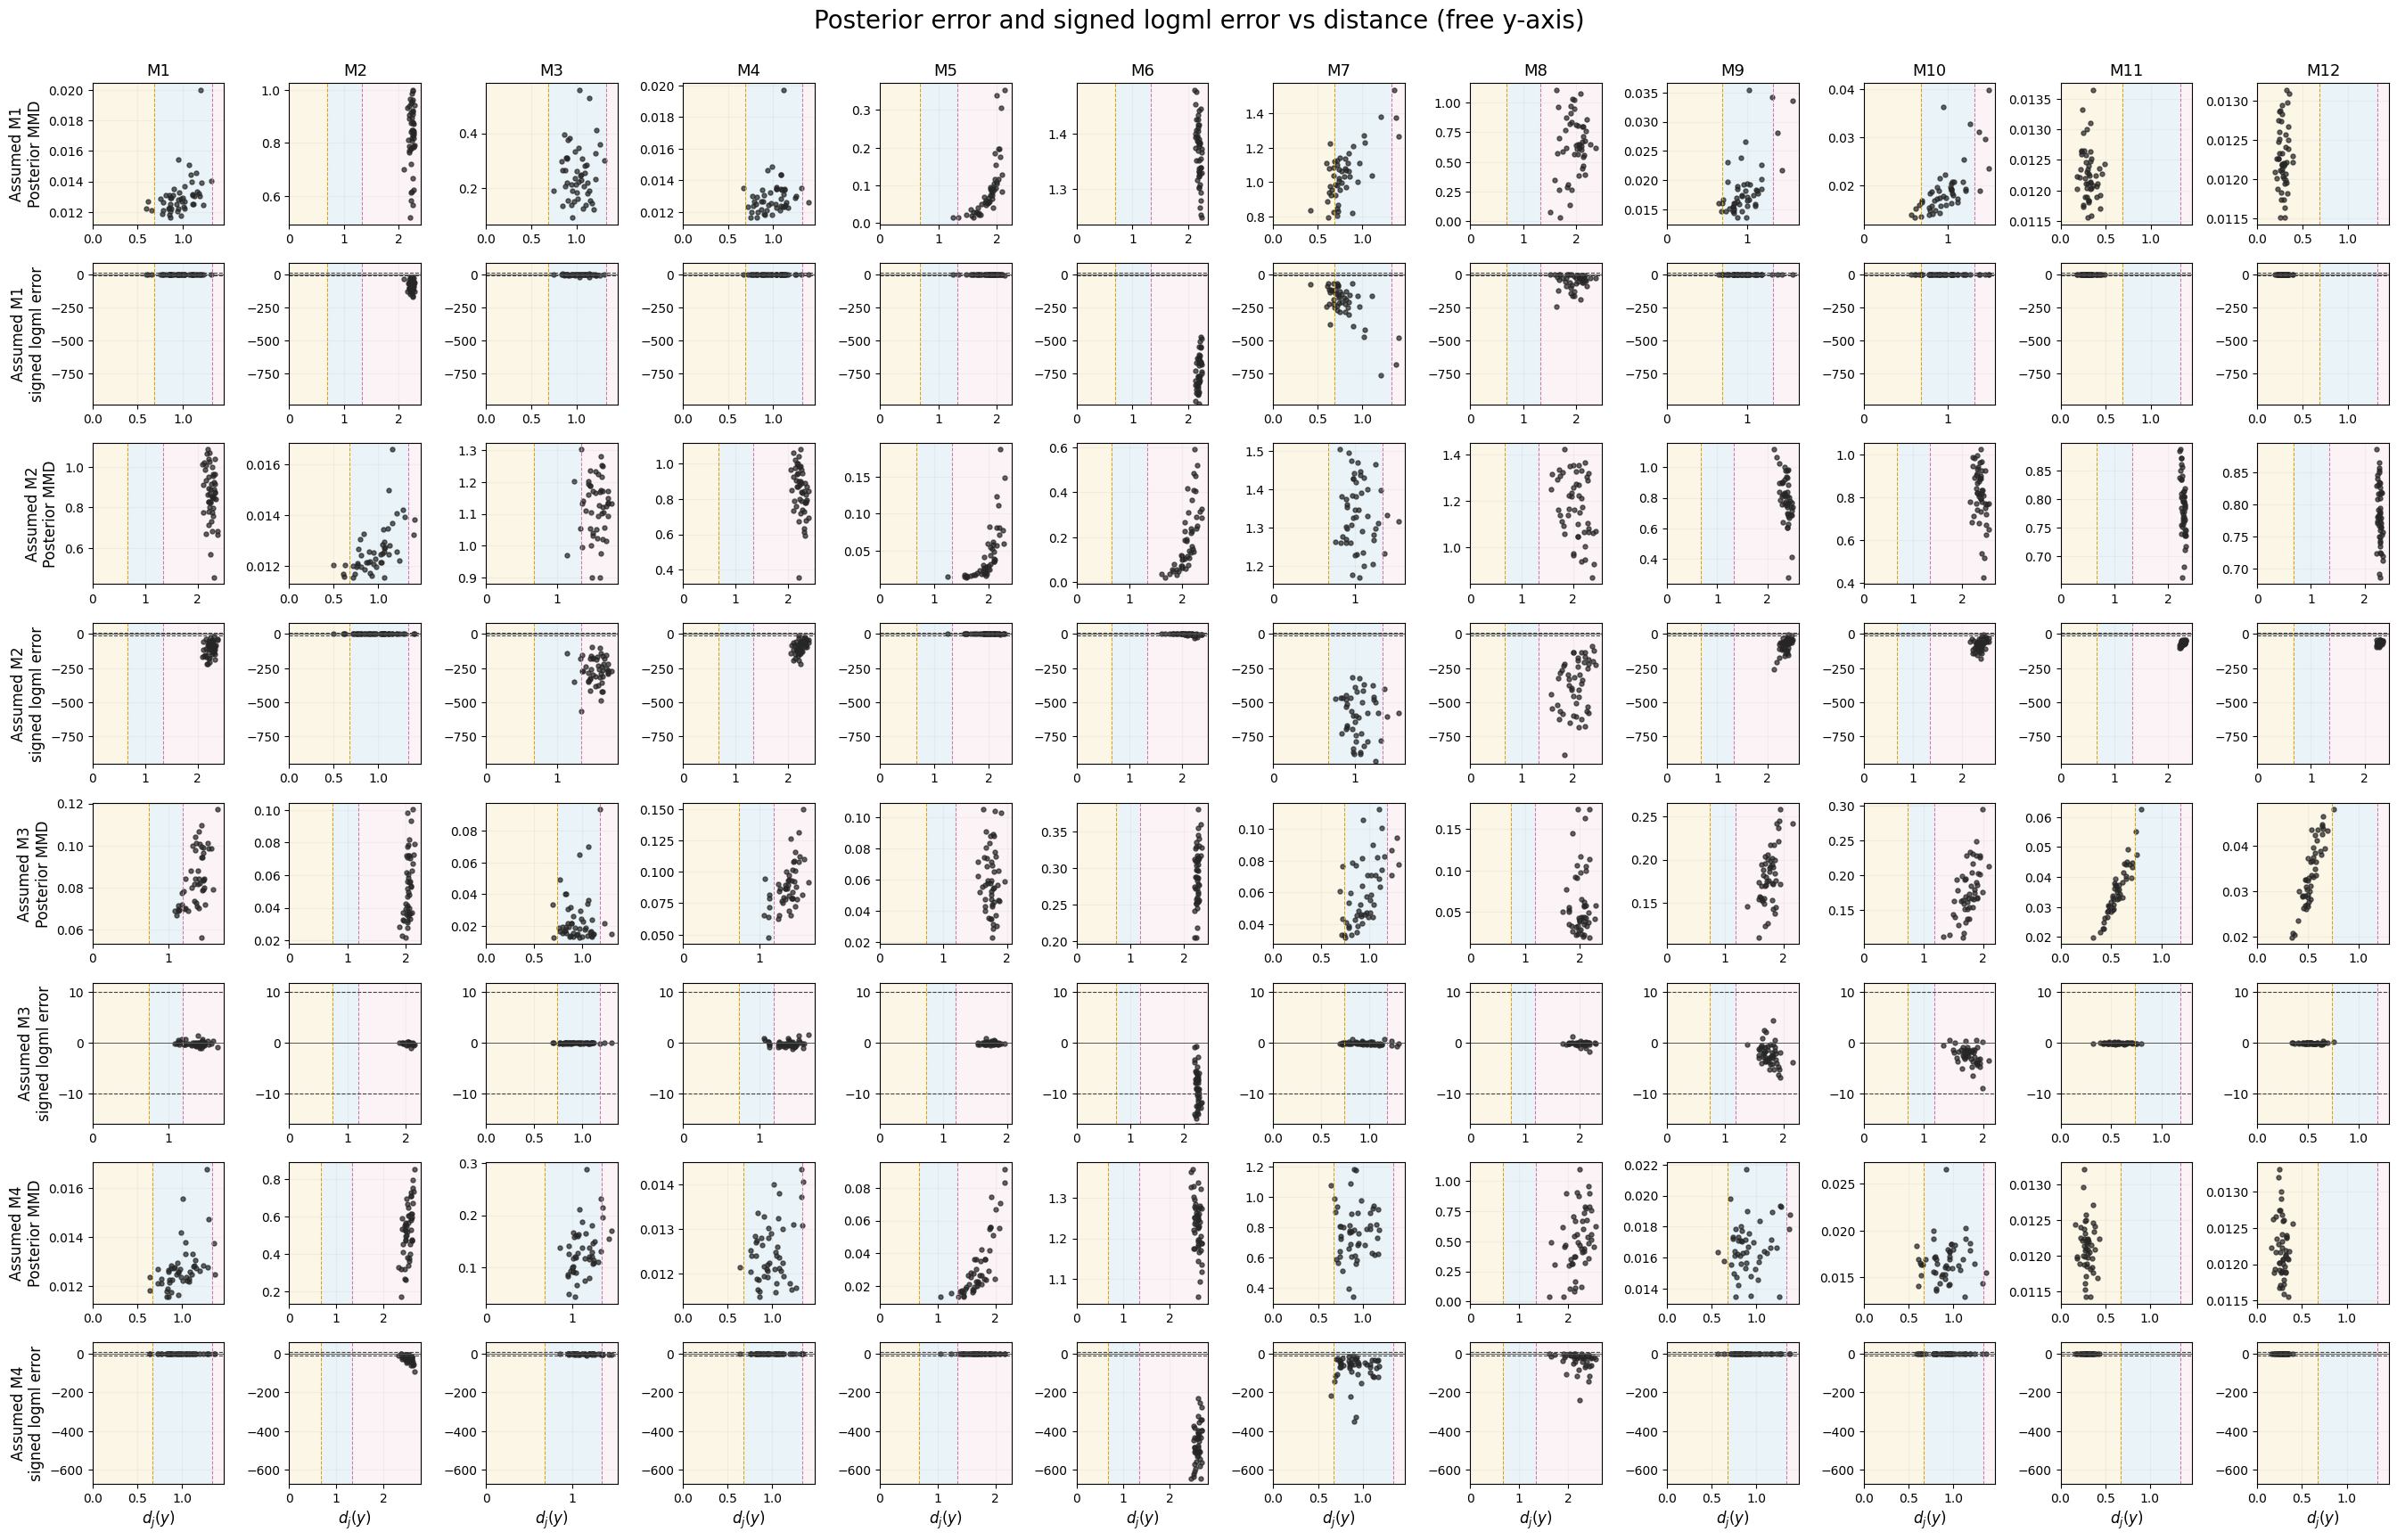

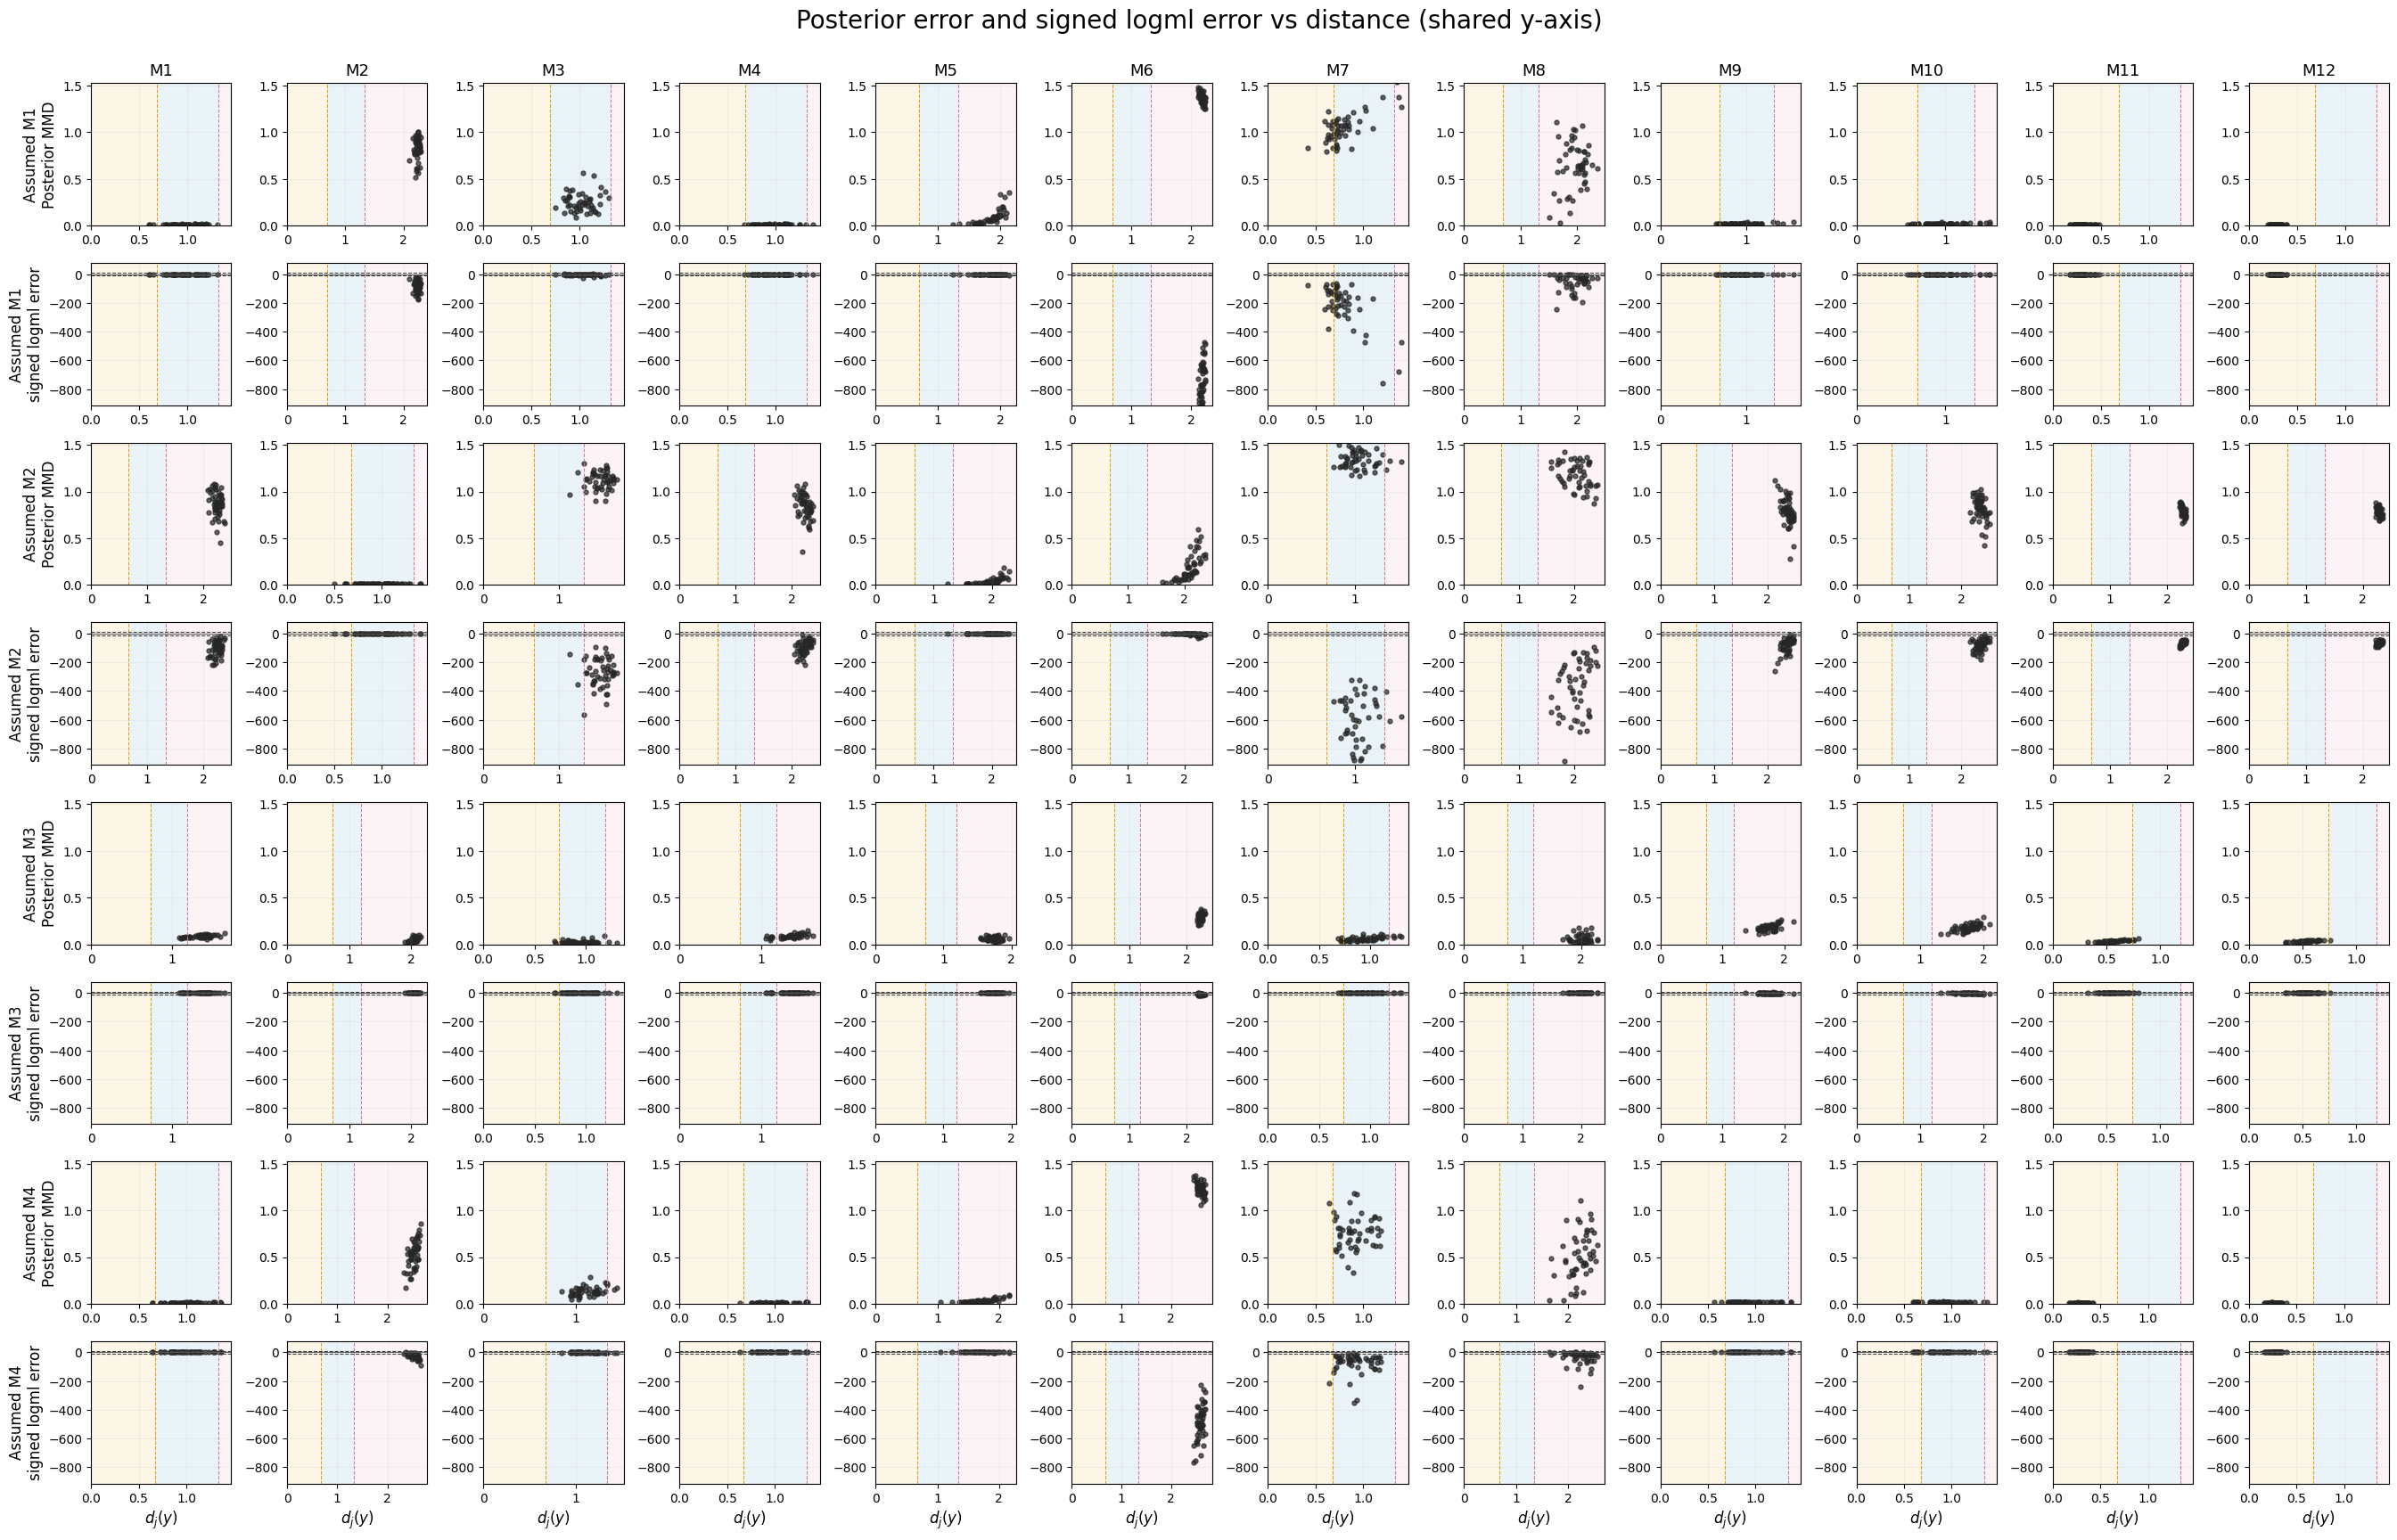

In [17]:
def safe_log(x):
    return np.log(np.maximum(np.asarray(x, dtype=float), 1e-12))


def add_distance_regions(ax, low, high, x_max, x_min=0.0):
    ax.axvspan(x_min, low, color="#F3D38B", alpha=0.20, lw=0)
    ax.axvspan(low, high, color="#9ECAE1", alpha=0.22, lw=0)
    ax.axvspan(high, x_max, color="#F2B6CC", alpha=0.16, lw=0)
    ax.axvline(low, color="#E69F00", linestyle="--", linewidth=0.75)
    ax.axvline(high, color="#CC79A7", linestyle="--", linewidth=0.75)


def robust_logml_ylim(values, threshold=10.0, lower_q=1.0, upper_q=99.0):
    finite = np.asarray(values[np.isfinite(values)], dtype=float)
    if finite.size == 0:
        return -1.5 * threshold, 1.5 * threshold
    low, high = np.percentile(finite, [lower_q, upper_q])
    low = min(float(low), -threshold, 0.0)
    high = max(float(high), threshold, 0.0)
    pad = 0.08 * max(high - low, 1.0)
    return low - pad, high + pad


def plot_stacked_posterior_logml_distance_grid(
    posterior_df,
    logml_df,
    posterior_metric="mmd",
    x="distance",
    logml_threshold=10.0,
    sharey=False,
    output_dir=None,
    filename=None,
):
    metrics = {
        "mmd": ("posterior_mmd", "Posterior MMD"),
        "mean_rmse": ("posterior_mean_rmse", "Posterior mean RMSE"),
    }
    if posterior_metric not in metrics:
        raise ValueError("posterior_metric must be 'mmd' or 'mean_rmse'")
    if x not in {"distance", "log_distance", "logdistance"}:
        raise ValueError("x must be 'distance' or 'log_distance'")

    metric_col, metric_label = metrics[posterior_metric]
    use_log = x in {"log_distance", "logdistance"}
    x_min = -0.5 if use_log else 0.0
    n_assumed = len(sd.ASSUMED_MODELS)
    n_sources = len(sd.SOURCE_MODELS)
    n_rows = 2 * n_assumed

    fig, axes = plt.subplots(
        n_rows,
        n_sources,
        figsize=(2.25 * n_sources, 2.15 * n_rows),
        sharey=False,
    )
    axes = np.atleast_2d(axes)

    if sharey:
        post_ylim = (
            0.0,
            float(posterior_df[metric_col].quantile(0.99)) * 1.08,
        )
        logml_ylim_global = robust_logml_ylim(logml_df["signed_logml_error"], threshold=logml_threshold)
    else:
        post_ylim = None
        logml_ylim_global = None

    for r, assumed in enumerate(sd.ASSUMED_MODELS):
        post_row = 2 * r
        logml_row = 2 * r + 1
        assumed_logml = logml_df[logml_df["assumed_model"].eq(assumed)]
        logml_ylim = logml_ylim_global if sharey else robust_logml_ylim(assumed_logml["signed_logml_error"], threshold=logml_threshold)

        for c, source in enumerate(sd.SOURCE_MODELS):
            post_ax = axes[post_row, c]
            logml_ax = axes[logml_row, c]

            post = posterior_df[(posterior_df["assumed_model"].eq(assumed)) & (posterior_df["source_model"].eq(source))].copy()
            logml = logml_df[(logml_df["assumed_model"].eq(assumed)) & (logml_df["source_model"].eq(source))].copy()

            for ax, sub, y_col in [(post_ax, post, metric_col), (logml_ax, logml, "signed_logml_error")]:
                if sub.empty:
                    ax.set_visible(False)
                    continue
                x_values = safe_log(sub["d_M"]) if use_log else sub["d_M"]
                low = float(safe_log(sub["dm_low"].iloc[0])) if use_log else float(sub["dm_low"].iloc[0])
                high = float(safe_log(sub["dm_high"].iloc[0])) if use_log else float(sub["dm_high"].iloc[0])
                x_max = max(float(np.max(x_values)) * 1.05, high * 1.1)
                add_distance_regions(ax, low, high, x_max, x_min=x_min)
                ax.scatter(x_values, sub[y_col], s=13, color="0.15", alpha=0.72)
                ax.set_xlim(x_min, x_max)
                ax.grid(alpha=0.13)

            if post_ylim is not None:
                post_ax.set_ylim(*post_ylim)

            logml_ax.axhline(0, color="0.35", linewidth=0.7)
            logml_ax.axhline(logml_threshold, color="0.25", linestyle="--", linewidth=0.8)
            logml_ax.axhline(-logml_threshold, color="0.25", linestyle="--", linewidth=0.8)
            logml_ax.set_ylim(*logml_ylim)

            if r == 0:
                post_ax.set_title(source.upper(), fontsize=13)
            if c == 0:
                post_ax.set_ylabel(f"Assumed {assumed.upper()}\n{metric_label}", fontsize=12)
                logml_ax.set_ylabel(f"Assumed {assumed.upper()}\nsigned logml error", fontsize=12)
            if logml_row == n_rows - 1:
                logml_ax.set_xlabel(r"$\log d_j(y)$" if use_log else r"$d_j(y)$", fontsize=12)

    title_suffix = "shared y-axis" if sharey else "free y-axis"
    fig.suptitle(f"Posterior error and signed logml error vs distance ({title_suffix})", fontsize=20, y=1.002)
    fig.tight_layout()

    if output_dir is not None:
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        share_suffix = "sharey" if sharey else "free_y"
        fig.savefig(Path(output_dir) / (filename or f"stacked_posterior_logml_distance_grid_{posterior_metric}_{share_suffix}.png"), dpi=220, bbox_inches="tight")

    return fig, axes


fig, axes = plot_stacked_posterior_logml_distance_grid(
    posterior_df,
    logml_df,
    posterior_metric="mmd",
    x="distance",
    logml_threshold=logml_error_threshold,
    sharey=False,
    output_dir=figure_dir,
)

fig_sharey, axes_sharey = plot_stacked_posterior_logml_distance_grid(
    posterior_df,
    logml_df,
    posterior_metric="mmd",
    x="distance",
    logml_threshold=logml_error_threshold,
    sharey=True,
    output_dir=figure_dir,
)